In [ ]:
# %pip install -q langchain-openai langchain-community langchain-core requests duckduckgo-search

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
import requests
from langchain_community.tools import DuckDuckGoSearchRun

d:\AgenticAI\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\iampr\AppData\Local\Temp\ipykernel_12572\1157012086.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [2]:
search_tool = DuckDuckGoSearchRun()

In [3]:
results = search_tool.invoke('top new in india today')

In [4]:
results

'New friction point between India, US: Return-home rule for Green Card applicants. Business. Old iPods, off-grid holidays, Lego bricks: Switching off the phone is new and growing market. Columns. Check out the latest news from India and around the world. Latest India news on Bollywood, Politics, Business, Cricket, Technology and Travel. Many Indian immigrants on employment and student visas rely on getting their green card while they’re still in the US. The new rule adds further uncertainty to the process. CEO Mark Zuckerberg\'s goodbye memo to 8,000 fired Meta staff has 2 promises for survivors. Today’s News Headlines, Explore the latest news, opinions, and features from New Indian Express. Stay informed with breaking news, in-depth coverage, and expert perspectives on various topics. Today\'s top India news headlines, news on Indian politics, elections, government, business, technology, and Bollywood."Well, it\'s not about India. It\'s about the whole world," US Secretary of State Ma

In [5]:
llm = ChatOpenAI()
llm.invoke('hi')

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DkqG6GP17FC5qtXjeVqfBnbFMikOp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e73a0-383f-70e1-831f-844932705271-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
# %pip install langchain-classic

In [7]:
from langchain_classic.agents import create_react_agent, AgentExecutor
from langchain_classic import hub

In [8]:
from langsmith.client import Client

client = Client()
prompt = client.pull_prompt(
    "hwchase17/react", 
    dangerously_pull_public_prompt=True
)

In [15]:
#react (reasoning + act)

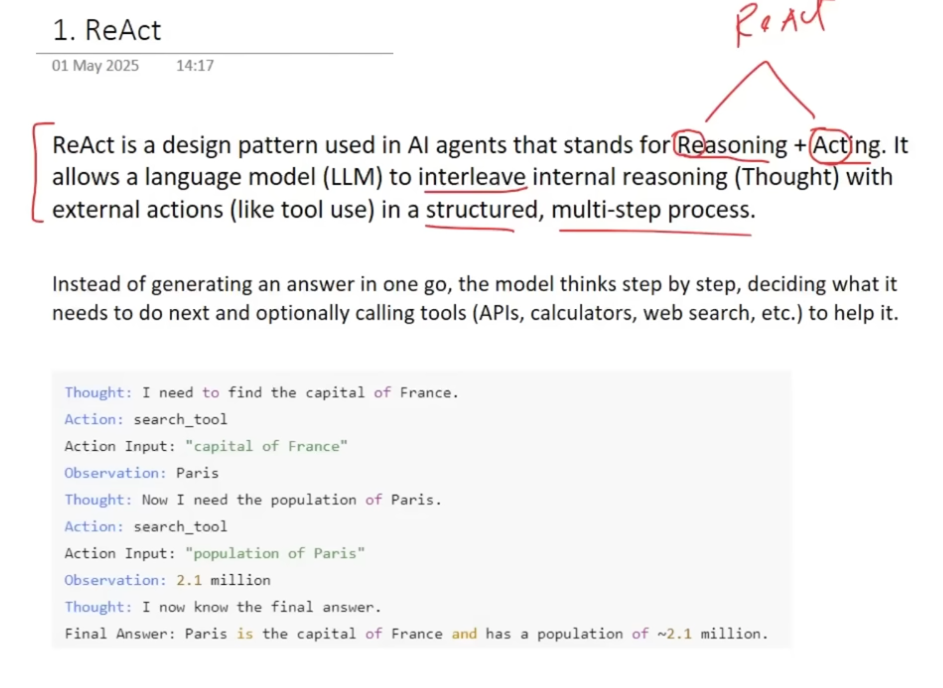

- Thought
- Action
- Observation

In [9]:
agent = create_react_agent(
    llm = llm,
    tools = [search_tool],
    prompt=prompt
)

In [10]:
agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool],
    verbose=True
)

In [15]:
response = agent_executor.invoke({'input':'whats the capital of india and its population'})



> Entering new AgentExecutor chain...
I should use DuckDuckGo Search to find the answer to this question
Action: duckduckgo_search
Action Input: capital of indiaDelhi, officially the National Capital Territory of Delhi, is a megacity and a union territory of India containing New Delhi, the capital of India. Discussion on the possibility of changing India's capital from New Delhi to Mumbai, Hyderabad, or Bangalore, described as beyond shocking. Republic of India. Abbreviations: IN, IND. Capital: New Delhi.Current Local Time in Locations in India with Links for More Information (597 Locations). The British originally ruled India from Calcutta, but moved the capital to the newly built district of New Delhi in 1911 because of the city’s symbolic value in India. India, the largest country in South Asia, has many of the world's highest mountains, most populated cities, and longest rivers.I still need to find the population of India
Action: duckduckgo_search
Action Input: population of Indi

In [16]:
print(response)
print(response['output'])

{'input': 'whats the capital of india and its population', 'output': 'The capital of India is New Delhi and the population of India is approximately 1.4 billion.'}
The capital of India is New Delhi and the population of India is approximately 1.4 billion.
